# Exploratory Data Analysis — Industrial Defect Detection

This notebook explores the dataset and validates the segmentation
pipeline used in `src/`. It produces the visualizations referenced
in the project README.

**Contents:**
1. Setup — import project modules
2. Class samples — one example image + ground-truth bbox + mask per class
3. Segmentation test — compare predicted vs ground-truth bounding boxes
4. Feature separability — how well the 10 extracted features distinguish classes

## 1. Setup

Import project modules from `src/` so we reuse the exact same
segmentation and config logic used in training and prediction —
no code duplication.

In [2]:

import sys
import os

sys.path.append(os.path.abspath(".."))

import cv2
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from src.config import TRAIN_DIR, VAL_DIR, OUTPUT_DIR, CLASSES, imread_unicode, imread_unicode_gray
from src.segmentation import segment_defect

print("Setup OK")
print("TRAIN_DIR:", TRAIN_DIR)

Setup OK
TRAIN_DIR: D:\Software\Bootcamps\Teknokent İleri Bilişim Teknolojileri Kurs\Hafta-8-goruntu-isleme\gun-5-uygulama\Proje\train


## 2. Class Samples

One example per class, showing the original image with its
ground-truth bounding box (green) and the corresponding defect mask.
This illustrates the visual signature of each defect type:

- **scratch** — thin elongated line
- **stain** — dark, filled blob inside the product
- **missing_part** — bright circular gap at the product edge
- **deformation** — small shape distortion at the product edge

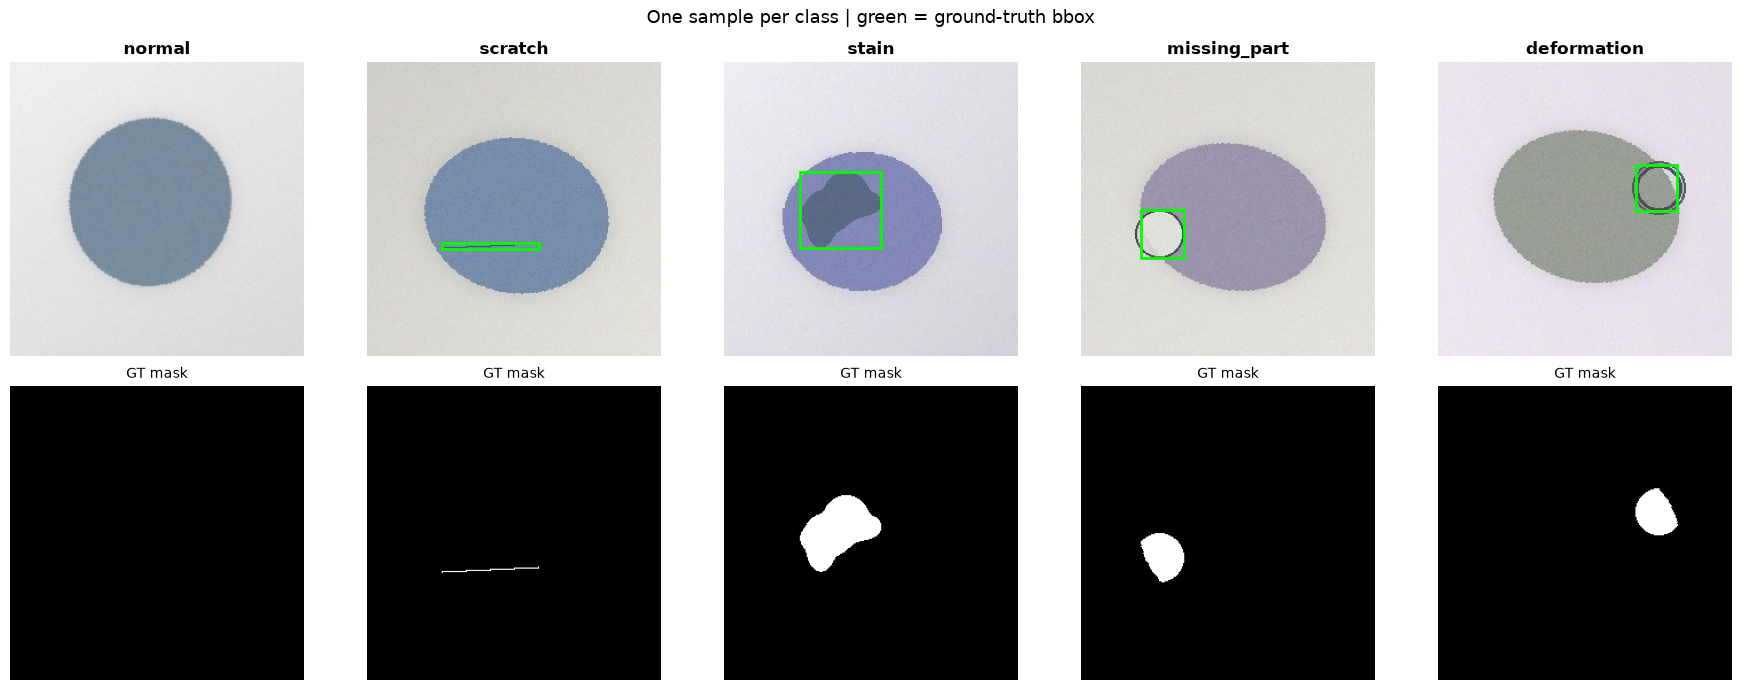

Saved -> D:\Software\Bootcamps\Teknokent İleri Bilişim Teknolojileri Kurs\Hafta-8-goruntu-isleme\gun-5-uygulama\Proje\defect_detection\outputs/class_samples.png


In [3]:
# Load train labels
with open(f"{TRAIN_DIR}/labels.csv", newline="", encoding="utf-8") as f:
    import csv
    train_rows = list(csv.DictReader(f))

# Plot one example per class: image + GT bbox (top row), mask (bottom row)
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for ci, cname in enumerate(CLASSES):
    sample = next(r for r in train_rows if r["class_name"] == cname)

    img = cv2.cvtColor(
        imread_unicode(f"{TRAIN_DIR}/images/{sample['image_id']}"),
        cv2.COLOR_BGR2RGB)
    mask = imread_unicode_gray(f"{TRAIN_DIR}/masks/{sample['mask_file']}") \
    if sample.get("mask_file") else np.zeros_like(img[:, :, 0])

    # Top row: image with GT bounding box
    axes[0, ci].imshow(img)
    x1, y1, x2, y2 = (int(sample[k]) for k in ["x1", "y1", "x2", "y2"])
    if (x1, y1, x2, y2) != (0, 0, 0, 0):
        axes[0, ci].add_patch(patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor="lime", facecolor="none"))
    axes[0, ci].set_title(cname, fontsize=12, fontweight="bold")
    axes[0, ci].axis("off")

    # Bottom row: ground-truth mask
    axes[1, ci].imshow(mask, cmap="gray")
    axes[1, ci].set_title("GT mask", fontsize=10)
    axes[1, ci].axis("off")

plt.suptitle("One sample per class | green = ground-truth bbox", fontsize=13)
plt.tight_layout()

# Save for README
save_path = f"{OUTPUT_DIR}/class_samples.png"
plt.savefig(save_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"Saved -> {save_path}")

## 3. Segmentation Test

Testing `segment_defect()` (from `src/segmentation.py`) on one sample
per class. The raw predicted bounding box (red) tends to be slightly
larger than the ground-truth box (green) — this systematic bias is
corrected in `predict.py` using a per-class shrink factor learned from
the train set.

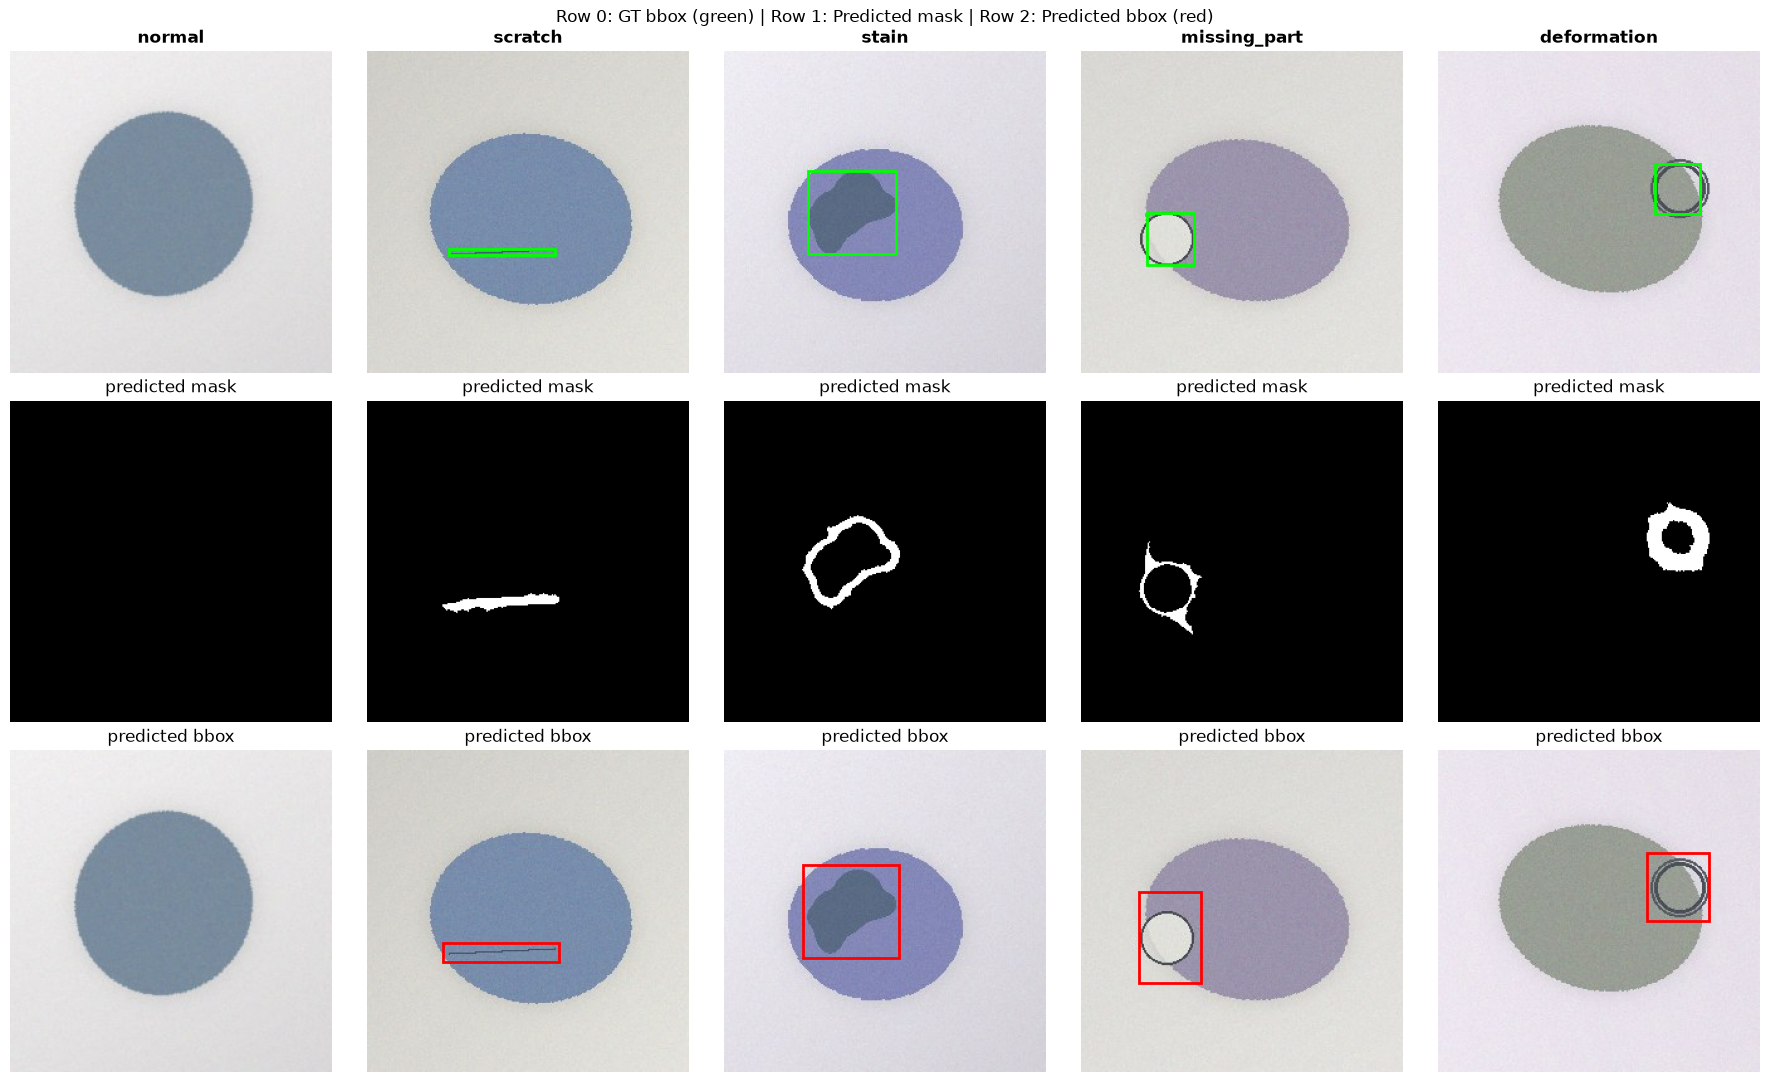

Saved -> D:\Software\Bootcamps\Teknokent İleri Bilişim Teknolojileri Kurs\Hafta-8-goruntu-isleme\gun-5-uygulama\Proje\defect_detection\outputs/segmentation_test.png


In [4]:
# Test segment_defect() on one sample per class
fig, axes = plt.subplots(3, 5, figsize=(18, 11))

for ci, cname in enumerate(CLASSES):
    sample = next(r for r in train_rows if r["class_name"] == cname)
    img = imread_unicode(f"{TRAIN_DIR}/images/{sample['image_id']}")
    pred_mask, pred_box = segment_defect(img)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Row 0: original image + GT bbox (green)
    axes[0, ci].imshow(img_rgb)
    gx1, gy1, gx2, gy2 = (int(sample[k]) for k in ["x1", "y1", "x2", "y2"])
    if (gx1, gy1, gx2, gy2) != (0, 0, 0, 0):
        axes[0, ci].add_patch(patches.Rectangle(
            (gx1, gy1), gx2 - gx1, gy2 - gy1,
            linewidth=2, edgecolor="lime", facecolor="none"))
    axes[0, ci].set_title(cname, fontweight="bold")
    axes[0, ci].axis("off")

    # Row 1: predicted mask from segment_defect()
    axes[1, ci].imshow(pred_mask, cmap="gray")
    axes[1, ci].set_title("predicted mask")
    axes[1, ci].axis("off")

    # Row 2: original image + predicted bbox (red)
    axes[2, ci].imshow(img_rgb)
    px1, py1, px2, py2 = pred_box
    if pred_box != (0, 0, 0, 0):
        axes[2, ci].add_patch(patches.Rectangle(
            (px1, py1), px2 - px1, py2 - py1,
            linewidth=2, edgecolor="red", facecolor="none"))
    axes[2, ci].set_title("predicted bbox")
    axes[2, ci].axis("off")

plt.suptitle("Row 0: GT bbox (green) | Row 1: Predicted mask | Row 2: Predicted bbox (red)")
plt.tight_layout()

save_path = f"{OUTPUT_DIR}/segmentation_test.png"
plt.savefig(save_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"Saved -> {save_path}")

## 4. Effect of Shrink Correction

The raw segmentation bbox (red, above) is systematically larger than
the ground truth. `predict.py` learns a per-class shrink factor from
the train set and applies it at prediction time. Here we show the
same samples with shrink correction applied, for comparison.

Learned shrink factors:
  stain          : width=0.900, height=0.892
  missing_part   : width=0.765, height=0.721
  deformation    : width=0.721, height=0.715
  scratch        : width=0.970, height=1.585


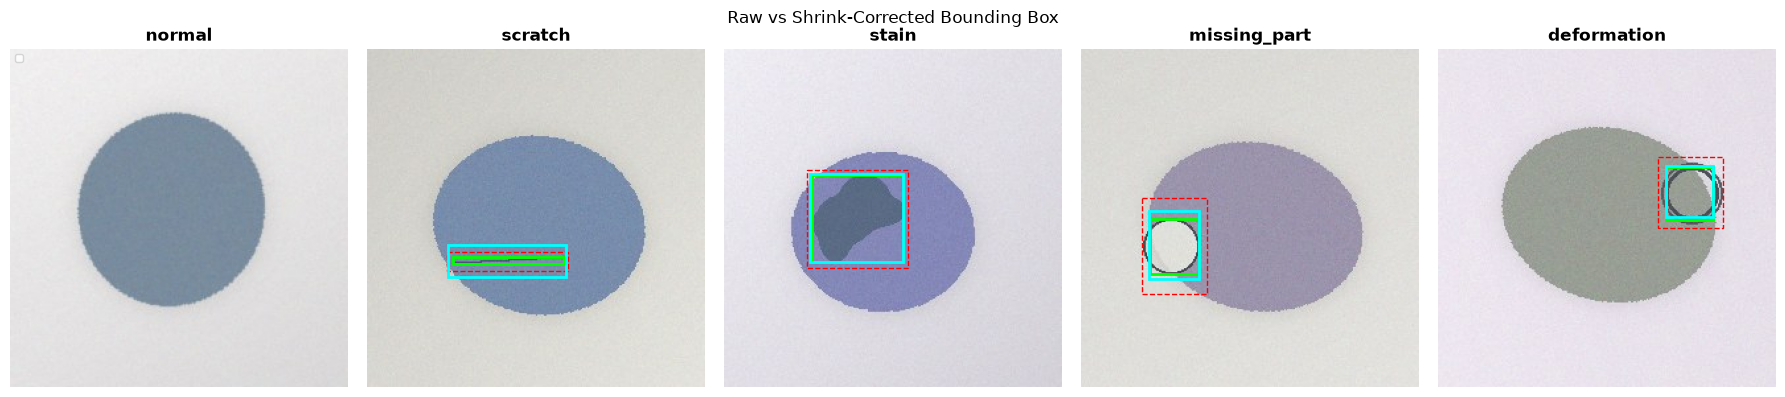

Saved -> D:\Software\Bootcamps\Teknokent İleri Bilişim Teknolojileri Kurs\Hafta-8-goruntu-isleme\gun-5-uygulama\Proje\defect_detection\outputs/shrink_comparison.png


In [5]:
# Compare raw vs shrink-corrected bbox for one elongated example (scratch)
# This demonstrates why shrink correction matters

import sys
sys.path.append("..")
from src.predict import learn_shrink_factors, shrink_box
from src.train import load_labels

shrink_factors = learn_shrink_factors(train_rows)
print("Learned shrink factors:")
for cls, (fw, fh) in shrink_factors.items():
    print(f"  {cls:15s}: width={fw:.3f}, height={fh:.3f}")

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ci, cname in enumerate(CLASSES):
    sample = next(r for r in train_rows if r["class_name"] == cname)
    img = imread_unicode(f"{TRAIN_DIR}/images/{sample['image_id']}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    _, raw_box = segment_defect(img)
    if cname != "normal" and raw_box != (0, 0, 0, 0):
        fx, fy = shrink_factors.get(cname, (1.0, 1.0))
        corrected_box = shrink_box(raw_box, fx, fy)
    else:
        corrected_box = raw_box

    axes[ci].imshow(img_rgb)
    gx1, gy1, gx2, gy2 = (int(sample[k]) for k in ["x1", "y1", "x2", "y2"])
    if (gx1, gy1, gx2, gy2) != (0, 0, 0, 0):
        axes[ci].add_patch(patches.Rectangle(
            (gx1, gy1), gx2 - gx1, gy2 - gy1,
            linewidth=2, edgecolor="lime", facecolor="none", label="GT"))
    if raw_box != (0, 0, 0, 0):
        rx1, ry1, rx2, ry2 = raw_box
        axes[ci].add_patch(patches.Rectangle(
            (rx1, ry1), rx2 - rx1, ry2 - ry1,
            linewidth=1, edgecolor="red", facecolor="none",
            linestyle="--", label="raw pred"))
    if corrected_box != (0, 0, 0, 0):
        cx1, cy1, cx2, cy2 = corrected_box
        axes[ci].add_patch(patches.Rectangle(
            (cx1, cy1), cx2 - cx1, cy2 - cy1,
            linewidth=2, edgecolor="cyan", facecolor="none", label="shrink-corrected"))

    axes[ci].set_title(cname, fontweight="bold")
    axes[ci].axis("off")

axes[0].legend(loc="upper left", fontsize=7,
                labels=["GT (green)", "raw pred (red, dashed)", "corrected (cyan)"])
plt.suptitle("Raw vs Shrink-Corrected Bounding Box")
plt.tight_layout()

save_path = f"{OUTPUT_DIR}/shrink_comparison.png"
plt.savefig(save_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"Saved -> {save_path}")

## 5. Classification Performance

The confusion matrix and classification metrics are generated by
`src/train.py` (see `outputs/confusion_matrix.png`). Final validation
and test scores are summarized in the project README.